# 01 — Data Exploration

Load the `.cxw` experiment file and visualise the raw GCI sensorgram data.

**Contents:**
1. Dataset overview (samples, blanks, DMSO cals)
2. Raw signal visualisation (active, reference, signal)
3. Injection markers & cycle structure
4. Compound / concentration inventory
5. Non-specific binder screening

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from creoptix_fitting.data_loader import load_cxw
from creoptix_fitting.models import is_nonspecific_binder

CXW = '../20250826_DENV-2 NS2B3 Binding Assay.cxw'
data = load_cxw(CXW)

samples = data['samples']
blanks = data['blanks']
dmso_cals = data['dmso_cals']

print(f'Samples:   {len(samples)}')
print(f'Blanks:    {len(blanks)}')
print(f'DMSO Cals: {len(dmso_cals)}')
print(f'Total:     {len(samples) + len(blanks) + len(dmso_cals)}')

Samples:   75
Blanks:    34
DMSO Cals: 8
Total:     117


## 1. Compound & Concentration Inventory

In [2]:
rows = [{'compound': s['compound'],
         'concentration_uM': s['concentration_M'] * 1e6,
         'mw': s.get('mw', 0),
         'slot': s.get('slot', ''),
         'cycle_index': s['index']}
        for s in samples]

inv = pd.DataFrame(rows)
print(f'Unique compounds: {inv["compound"].nunique()}')
print(f'Concentration range: {inv["concentration_uM"].min():.1f} – {inv["concentration_uM"].max():.0f} µM')
print()
print('Replicates per compound:')
print(inv.groupby('compound')['concentration_uM'].apply(list).to_string())

Unique compounds: 62
Concentration range: 0.5 – 25 µM

Replicates per compound:
compound
ASAP-0017237                                 [24.999999999999996]
ASAP-0017634                                 [24.999999999999996]
ASAP-0017637                                 [24.999999999999996]
ASAP-0017666                                 [24.999999999999996]
ASAP-0029270                                 [24.999999999999996]
ASAP-0029295                                 [24.999999999999996]
ASAP-0029307                                 [24.999999999999996]
ASAP-0029352                                               [10.0]
ASAP-0029691                                 [24.999999999999996]
ASAP-0029804                                 [24.999999999999996]
ASAP-0029913                                 [24.999999999999996]
ASAP-0036612                                 [24.999999999999996]
ASAP-0036707                                 [24.999999999999996]
ASAP-0036713                                 [24.9999

## 2. Raw Sensorgram — Example Sample

Plot raw active (FC2), reference (FC1), and difference signal for a single sample cycle.

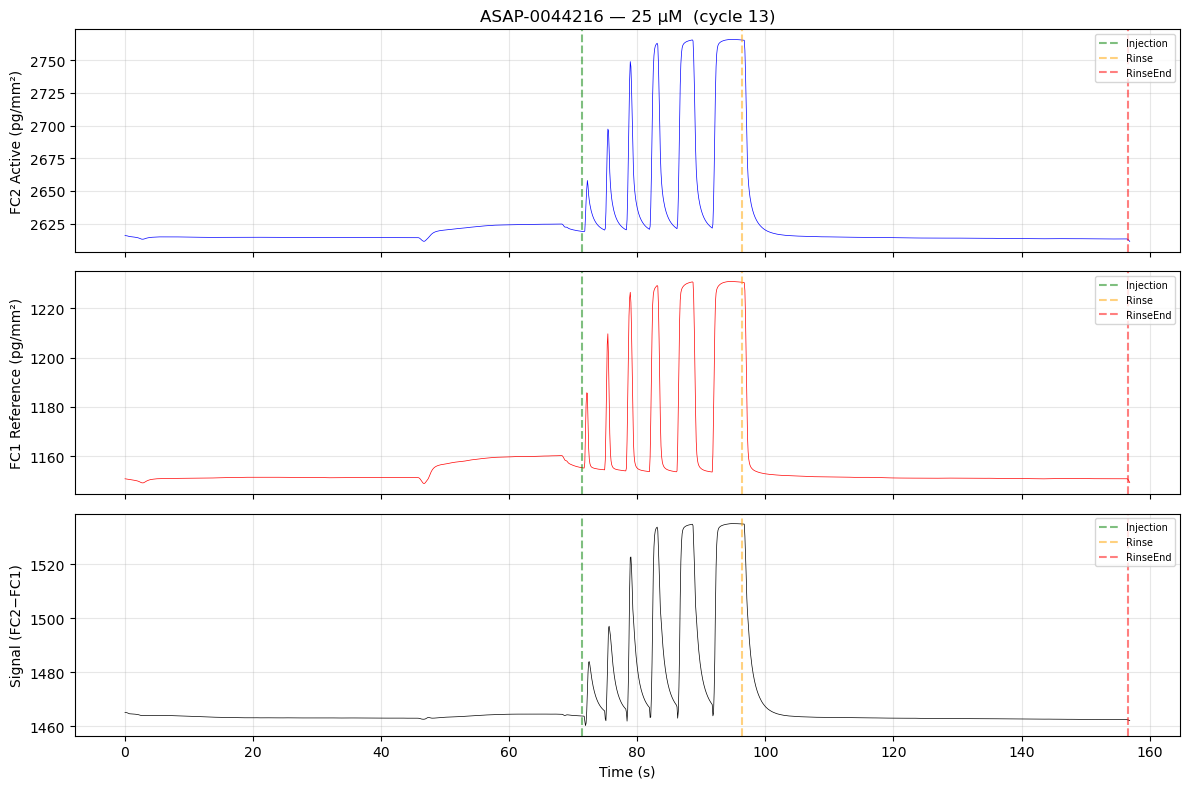

In [3]:
sample = samples[0]
t = sample['time']
markers = sample['markers']

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, sample['raw_active'], 'b-', lw=0.5)
axes[0].set_ylabel('FC2 Active (pg/mm²)')
axes[0].set_title(f'{sample["compound"]} — {sample["concentration_M"]*1e6:.0f} µM  (cycle {sample["index"]})')

axes[1].plot(t, sample['raw_reference'], 'r-', lw=0.5)
axes[1].set_ylabel('FC1 Reference (pg/mm²)')

axes[2].plot(t, sample['signal'], 'k-', lw=0.5)
axes[2].set_ylabel('Signal (FC2−FC1)')
axes[2].set_xlabel('Time (s)')

# Mark injection phases
for ax in axes:
    for name, color in [('Injection', 'green'), ('Rinse', 'orange'), ('RinseEnd', 'red')]:
        if name in markers:
            ax.axvline(markers[name], color=color, ls='--', alpha=0.5, label=name)
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Overlay — All Sample Sensorgrams

Plot all sample signals overlaid, coloured by compound.

/var/folders/7f/yv7byb4n5t1fdbk73n2w9h9w0000gp/T/ipykernel_35587/1877944863.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(compounds))


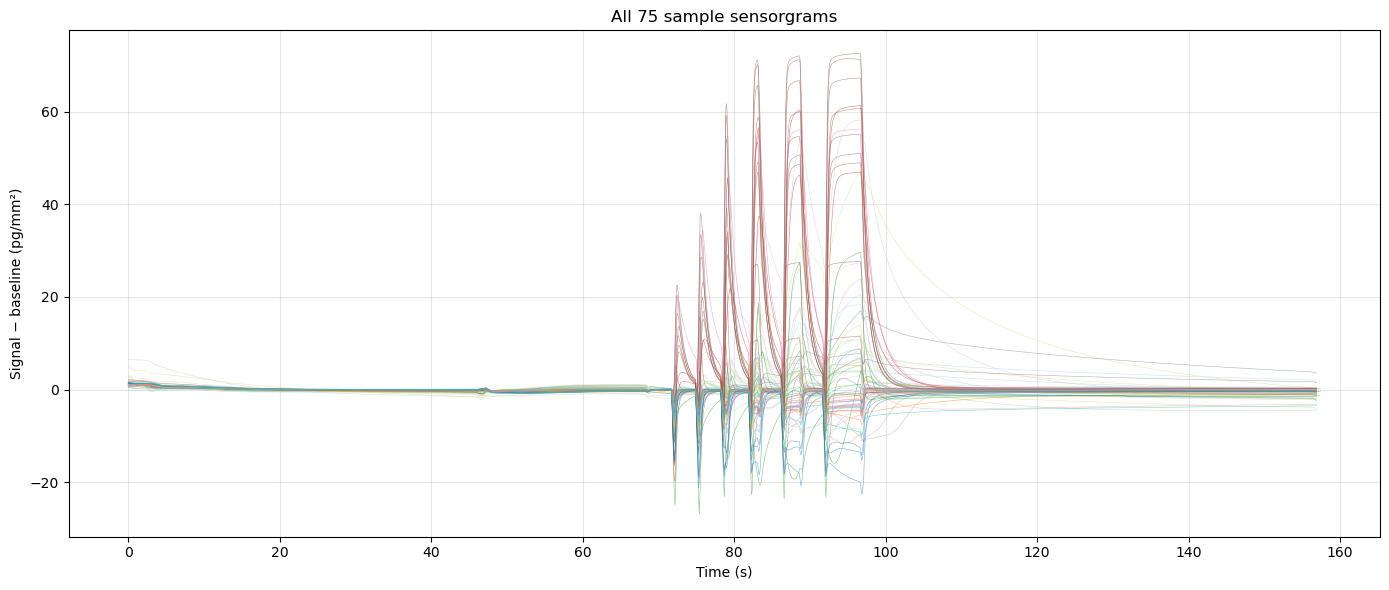

In [4]:
compounds = sorted(set(s['compound'] for s in samples))
cmap = plt.cm.get_cmap('tab20', len(compounds))
c_map = {c: cmap(i) for i, c in enumerate(compounds)}

fig, ax = plt.subplots(figsize=(14, 6))
for s in samples:
    t = s['time']
    # Baseline-subtract
    inj = s['markers'].get('Injection', t[0])
    bl = s['signal'][t < inj].mean() if (t < inj).any() else 0
    ax.plot(t, s['signal'] - bl, color=c_map[s['compound']], lw=0.4, alpha=0.6)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Signal − baseline (pg/mm²)')
ax.set_title(f'All {len(samples)} sample sensorgrams')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Pulsed Injection Structure (DMSO Cal)

View the raw DMSO cal cycle to visualise the alternating analyte/buffer pulse structure.

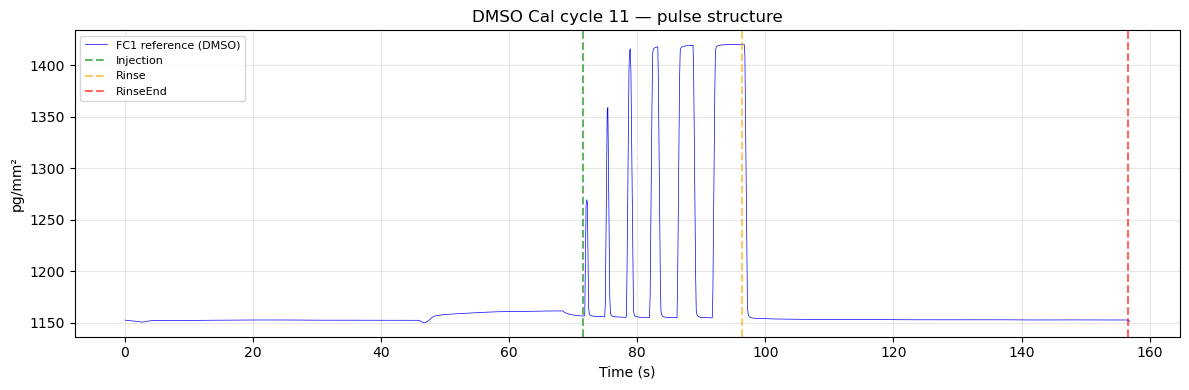

In [5]:
dmso = dmso_cals[0]
t_d = dmso['time']
m_d = dmso['markers']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_d, dmso['raw_reference'], 'b-', lw=0.5, label='FC1 reference (DMSO)')
for name, col in [('Injection', 'green'), ('Rinse', 'orange'), ('RinseEnd', 'red')]:
    if name in m_d:
        ax.axvline(m_d[name], color=col, ls='--', alpha=0.6, label=name)

ax.set_xlabel('Time (s)')
ax.set_ylabel('pg/mm²')
ax.set_title(f'DMSO Cal cycle {dmso["index"]} — pulse structure')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Non-Specific Binder Screening

Classify samples by reference channel dissociation signal. Samples with high reference retention (>2 pg/mm²) are non-specific binders.

In [6]:
nsb_data = []
for s in samples:
    is_nsb, ref_d = is_nonspecific_binder(s)
    nsb_data.append({'compound': s['compound'],
                     'concentration_uM': s['concentration_M'] * 1e6,
                     'ref_dissoc': ref_d,
                     'nonspecific': is_nsb})

nsb_df = pd.DataFrame(nsb_data).sort_values('ref_dissoc', ascending=False)
n_nsb = nsb_df['nonspecific'].sum()
n_spec = len(nsb_df) - n_nsb
print(f'Non-specific binders: {n_nsb}/{len(nsb_df)}')
print(f'Specific binders:     {n_spec}/{len(nsb_df)}')

Non-specific binders: 27/75
Specific binders:     48/75


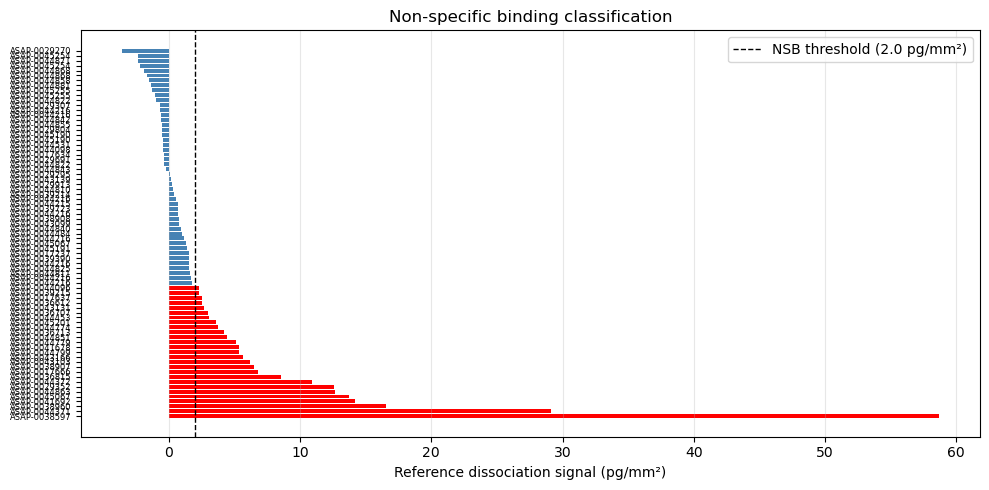

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red' if x else 'steelblue' for x in nsb_df['nonspecific']]
ax.barh(range(len(nsb_df)), nsb_df['ref_dissoc'].values, color=colors, height=0.8)
ax.axvline(2.0, color='k', ls='--', lw=1, label='NSB threshold (2.0 pg/mm²)')
ax.set_yticks(range(len(nsb_df)))
ax.set_yticklabels(nsb_df['compound'].values, fontsize=6)
ax.set_xlabel('Reference dissociation signal (pg/mm²)')
ax.set_title('Non-specific binding classification')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 6. Side-by-side: Specific vs Non-Specific Binder

Compare the reference channel behaviour.

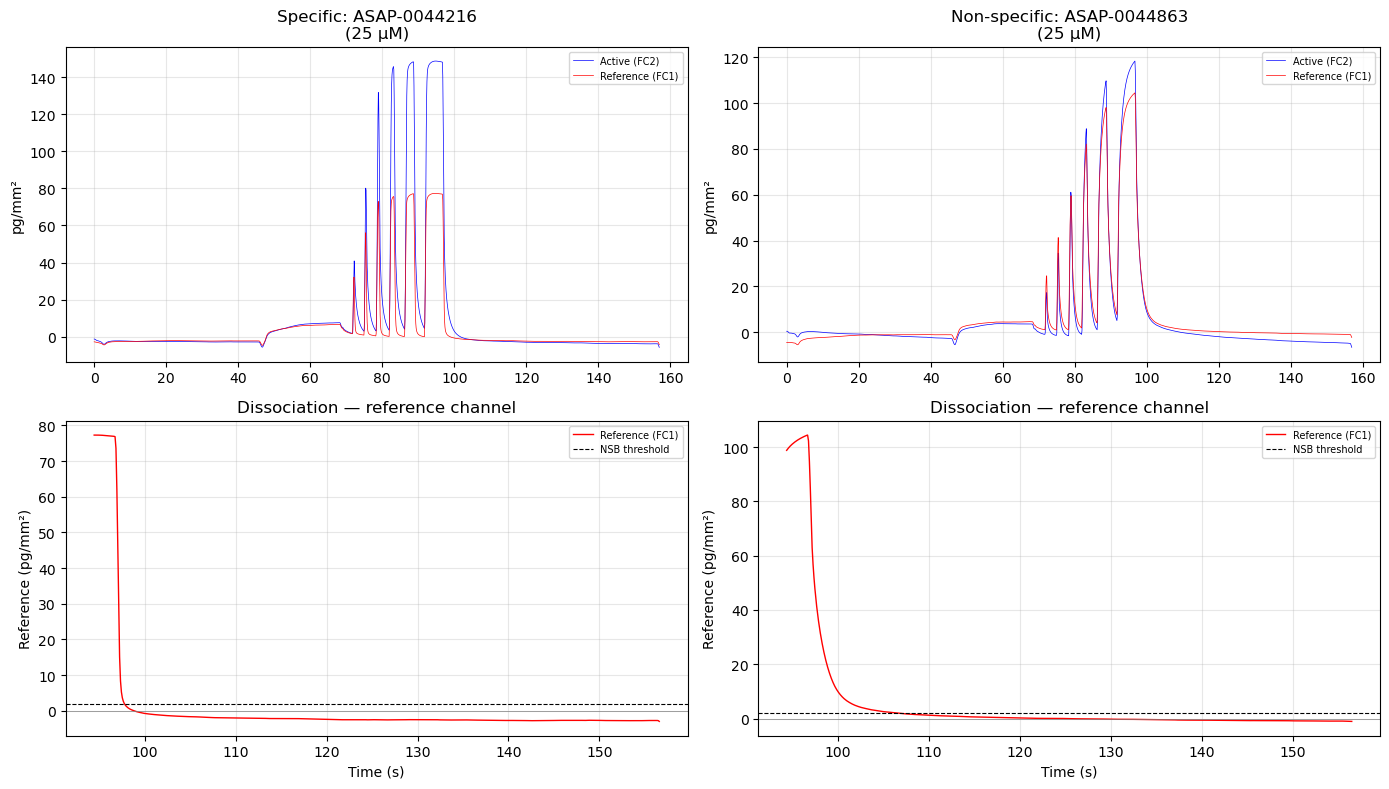

In [8]:
# Pick one specific and one non-specific
spec_sample = [s for s in samples if not is_nonspecific_binder(s)[0]][0]
nsb_sample = [s for s in samples if is_nonspecific_binder(s)[0]][0]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (s, label) in enumerate([(spec_sample, 'Specific'), (nsb_sample, 'Non-specific')]):
    t = s['time']
    inj = s['markers'].get('Injection', t[0])
    bl_act = s['raw_active'][t < inj].mean()
    bl_ref = s['raw_reference'][t < inj].mean()

    axes[0, col].plot(t, s['raw_active'] - bl_act, 'b-', lw=0.5, label='Active (FC2)')
    axes[0, col].plot(t, s['raw_reference'] - bl_ref, 'r-', lw=0.5, label='Reference (FC1)')
    axes[0, col].set_title(f'{label}: {s["compound"]}\n({s["concentration_M"]*1e6:.0f} µM)')
    axes[0, col].legend(fontsize=7)
    axes[0, col].set_ylabel('pg/mm²')
    axes[0, col].grid(True, alpha=0.3)

    # Zoom on dissociation
    rinse = s['markers'].get('Rinse', t[-1])
    rinse_end = s['markers'].get('RinseEnd', t[-1])
    d_mask = (t >= rinse - 2) & (t <= rinse_end)
    axes[1, col].plot(t[d_mask], s['raw_reference'][d_mask] - bl_ref, 'r-', lw=1, label='Reference (FC1)')
    axes[1, col].axhline(0, color='gray', ls='-', lw=0.5)
    axes[1, col].axhline(2.0, color='k', ls='--', lw=0.8, label='NSB threshold')
    axes[1, col].set_xlabel('Time (s)')
    axes[1, col].set_ylabel('Reference (pg/mm²)')
    axes[1, col].set_title(f'Dissociation — reference channel')
    axes[1, col].legend(fontsize=7)
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()